<a href="https://colab.research.google.com/github/niksisons/neural_networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%966_%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B0%D0%B2%D1%82%D0%BE%D1%8D%D0%BD%D0%BA%D0%BE%D0%B4%D0%B5%D1%80%D0%BE%D0%B2_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%BF%D1%80%D0%B8%D0%BA%D0%BB%D0%B0%D0%B4%D0%BD%D1%8B%D1%85_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №6. Проектирование автоэнкодеров для решения прикладных задач**


## **Задание №1. Реализуйте автоэнкодер для колоризации чёрно-белых изображений**



* **Чем больше объектов разных классов будет в исходном датасете, тем универсальнее будет работа обученной Вами модели**

> Например, если в Вашем датасете только кошки, то все объекты кроме кошек будут колоризоваться некорректно. Соответственно следует очень тщательно подойти к выбору датасета.

  * Для решения данной задачи может подойти датасет [CIFAR-100](https://www.kaggle.com/datasets/fedesoriano/cifar100), но его минус заключается в том, что разрешение изображений довольно низкое

* Хорошим вариантом будет использование датасета [ImageNet](https://paperswithcode.com/dataset/imagenet), но ввиду его объёмности, процесс обучения займет большое количество времени, поэтому Вы можете использовать одну из его [сокращенных версий](https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000)



 **Конечный выбор датасета осуществляется по Вашему желанию (хорошо, если это будут Ваши датасеты), учитывая рекомендации приведенные выше.**


In [19]:
import os
import kagglehub
from pathlib import Path
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# Загрузка датасета
path = kagglehub.dataset_download("pavansanagapati/images-dataset")
data_path = os.path.join(path, 'data')
if not os.path.exists(data_path): data_path = os.path.join(path, 'data')
if not os.path.exists(data_path): data_path = path

IMG_SIZE = (224, 224)
BATCH_SIZE = 2

dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True
)

# Глобальная переменная для всех заданий
normalized_ds = dataset.map(lambda x, y: x / 255.0)

def prepare_colorization_data(img):
    gray_img = tf.image.rgb_to_grayscale(img)
    return gray_img, img

colorization_dataset = normalized_ds.map(prepare_colorization_data)
print("Датасет успешно инициализирован.")

Using Colab cache for faster access to the 'images-dataset' dataset.
Found 3606 files belonging to 8 classes.
Датасет успешно инициализирован.


In [20]:
tf.keras.backend.clear_session()
gc.collect()

def build_colorization_autoencoder():
    encoder_input = layers.Input(shape=(224, 224, 1))
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # 112x112
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # 56x56
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.BatchNormalization()(x)

    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x) # 112x112
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x) # 224x224
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mae')
    return autoencoder

colorization_model = build_colorization_autoencoder()
train_ds = colorization_dataset.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
colorization_model.fit(train_ds, epochs=19)

Epoch 1/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 79s 36ms/step - loss: 0.0866
Epoch 2/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 62s 35ms/step - loss: 0.0669
Epoch 3/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0623
Epoch 4/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0600
Epoch 5/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0586
Epoch 6/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0578
Epoch 7/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0563
Epoch 8/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0559
Epoch 9/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0553
Epoch 10/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0550
Epoch 11/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0544
Epoch 12/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0539
Epoch 13/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 62s 34ms/step - loss: 0.0537
Epoch 14/19
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 61s 34ms/step - loss: 0.0532
E

## **Задание №2. Реализуйте автоэнкодер для удаления шума на однотипных изображениях**



1.  Подберите датасет, состоящий из однотипных изображений, которые в реальной жизни часто подвержены зашумлению, например спутниковые снимки, ночные фотографии и т.д.

2.  Затем примените к ним операцию зашумления и обучите модель. Также учитывайте тип шума, который Вы применяете. Он должен быть приближен к естественному.

Хороший пример реализации подобной задачи: https://www.kaggle.com/code/michalbrezk/denoise-images-using-autoencoders-tf-keras

In [10]:
def build_denoising_autoencoder():
    # Энкодер (вход 64x64x3)
    encoder_input = layers.Input(shape=(64, 64, 3))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Декодер
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

denoising_model = build_denoising_autoencoder()
denoising_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras import layers, models
import tensorflow as tf
import gc

# Очистка памяти перед началом
tf.keras.backend.clear_session()
gc.collect()

def prepare_denoising_data(img):
    img = tf.image.resize(img, (64, 64))
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.1, dtype=tf.float32)
    noisy_img = tf.clip_by_value(img + noise, 0.0, 1.0)
    return noisy_img, img

def build_denoising_autoencoder():
    encoder_input = layers.Input(shape=(64, 64, 3))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

denoising_model = build_denoising_autoencoder()
# Убираем .cache() если памяти совсем мало
denoising_ds = normalized_ds.unbatch().map(prepare_denoising_data).shuffle(500).batch(32).prefetch(tf.data.AUTOTUNE)

print("Обучение модели удаления шума...")
denoising_model.fit(denoising_ds, epochs=15)

gc.collect()

Обучение модели удаления шума...
Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 119ms/step - loss: 0.0244
Epoch 2/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0084
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0057
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0049
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - loss: 0.0045
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0040
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0038
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0040
Epoch 9/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0034
Epoch 10/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.0033
Epoch 11/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0032
Epoch 12/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0031
Epoch 13/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0031
Epoch 14/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0031
Epoch 15/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0029


1445

## **Задание №.3 Реализуйте автоэнкодер для улучшения качества изображения путём увеличения его разрешения (апскейлинг-[определение](https://dic.academic.ru/dic.nsf/ruwiki/346555))**



1. На входной слой нейронной сети подаётся изображение с размерностью (256, 256,3) - X_test. В результате работы нейронной сети на выходном слое должно получиться изображение (512, 512, 3) - Y_test. В итоге мы получаем двукратный апскейл исходного изображения.

2. Датасет собираете из изображений, разрешение которых выше эталонного (512,512,3). Затем преобразуете их в указанные размерности и формируете из них обучающую и проверочную выборку.

3. Обучите модель. Отобразите графики обучения

4. Подумайте, каким образом можно будет адаптировать модель вашей нейронной сети для двухратного апскейла изображения с любой размерностью, большей, чем (256,256,3), с полным или частичным сохранением его исходных пропорций. Например: подаём на вход изображение с разрешением (1920, 1080, 3) - получаем изображение с разрешением (3840, 2160, 3), т.е. с полным сохранением исходных пропорций или (1792, 1024, 3) с частичным сохранением исходных пропорций.

> Подсказка: Для этого можно реализовать алгоритм предварительной обработки исходного изображения, перед подачей его в нейронную сеть

In [13]:
def build_upscaling_autoencoder():
    # Вход: 256x256x3
    encoder_input = layers.Input(shape=(256, 256, 3))

    # Извлечение признаков (без сильного сжатия размерности, чтобы не терять детали)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # Апскейлинг в 2 раза
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

upscaling_model = build_upscaling_autoencoder()
upscaling_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 512, 512, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 512, 512, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 512, 512, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 512, 512, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,771 (659.26 KB)

 Trainable params: 168,771 (659.26 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras import layers, models
import tensorflow as tf
import gc

# Очистка памяти после предыдущей модели
tf.keras.backend.clear_session()
gc.collect()

def prepare_upscaling_data(img):
    hr_img = tf.image.resize(img, (512, 512))
    lr_img = tf.image.resize(img, (256, 256))
    return lr_img, hr_img

def build_upscaling_autoencoder():
    encoder_input = layers.Input(shape=(256, 256, 3))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x) # 512x512
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mae')
    return autoencoder

upscaling_model = build_upscaling_autoencoder()
# Уменьшаем BATCH_SIZE до 2 и убираем .cache() для экономии RAM
upscaling_ds = normalized_ds.unbatch().map(prepare_upscaling_data).shuffle(200).batch(2).prefetch(tf.data.AUTOTUNE)

print("Обучение модели апскейлинга...")
upscaling_model.fit(upscaling_ds, epochs=5)

gc.collect()

Обучение модели апскейлинга...
Epoch 1/5
902/902 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - loss: 0.0730
Epoch 2/5
902/902 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - loss: 0.0583
Epoch 3/5
902/902 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - loss: 0.0497
Epoch 4/5
902/902 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - loss: 0.0439
Epoch 5/5
902/902 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - loss: 0.0408


1213

## **Демонстрация результата задания №1: колоризация**

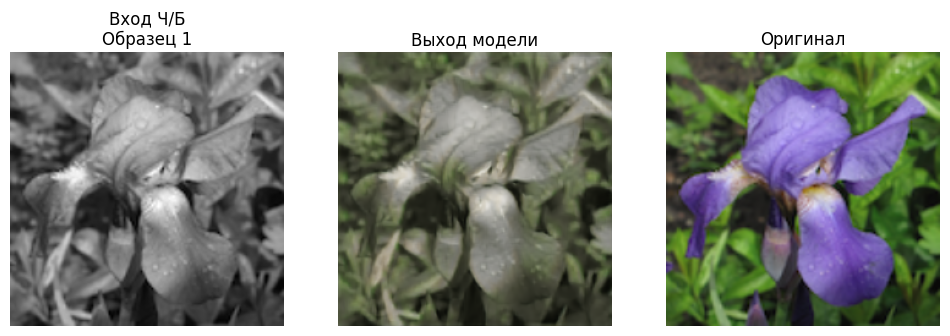

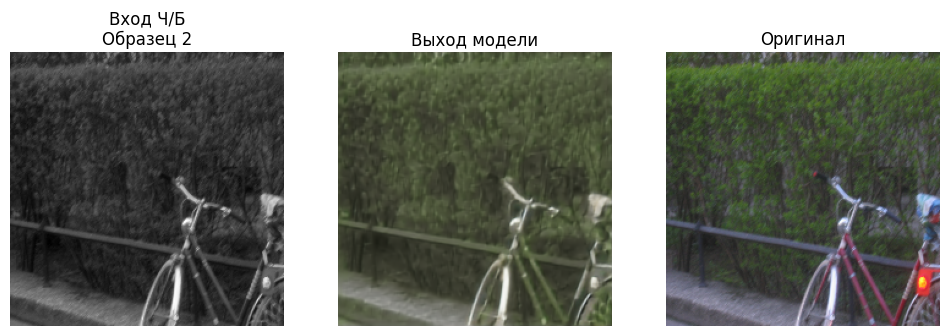

In [34]:
import matplotlib.pyplot as plt
import tensorflow as tf
import os

def load_demo_inputs(max_images=3):
    dataset_images = []
    # Берем 1 батч и извлекаем из него картинки
    for img_batch in normalized_ds.take(1):
        for i in range(min(len(img_batch), max_images)):
            dataset_images.append(img_batch[i])
    return dataset_images

def load_image_for_demo(image_source, target_size):
    """Нормализует изображение и меняет размер."""
    if isinstance(image_source, str):
        img_raw = tf.io.read_file(image_source)
        img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
        img = tf.image.resize(img, target_size)
        img = tf.cast(img, tf.float32) / 255.0
        return img

    # Если это уже тензор из датасета
    img = tf.image.resize(image_source, target_size)
    return img

def show_colorization_result(image_source, title_suffix=""):
    img = load_image_for_demo(image_source, (224, 224))
    gray_img = tf.image.rgb_to_grayscale(img)
    pred_img = colorization_model.predict(tf.expand_dims(gray_img, 0), verbose=0)[0]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title(f"Вход Ч/Б\n{title_suffix}")
    plt.imshow(tf.squeeze(gray_img), cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Выход модели")
    plt.imshow(tf.clip_by_value(pred_img, 0.0, 1.0))
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Оригинал")
    plt.imshow(tf.clip_by_value(img, 0.0, 1.0))
    plt.axis("off")
    plt.show()

if "colorization_model" not in globals():
    print("Сначала выполните ячейку обучения модели колоризации.")
else:
    demo_inputs = load_demo_inputs(max_images=3)
    for i, src in enumerate(demo_inputs, start=1):
        show_colorization_result(src, title_suffix=f"Образец {i}")

## **Демонстрация результата задания №2: удаление шума**

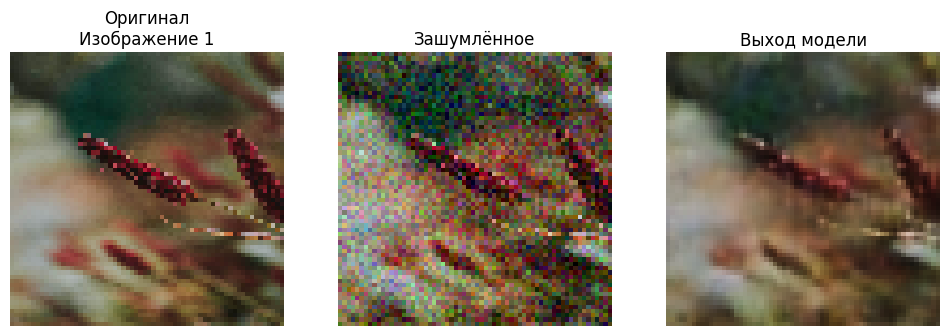

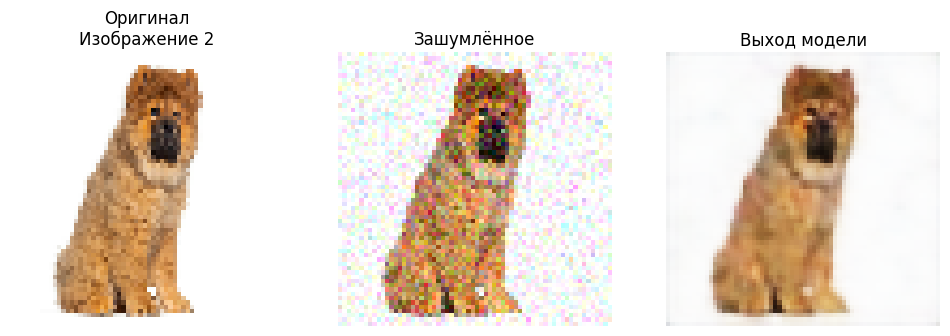

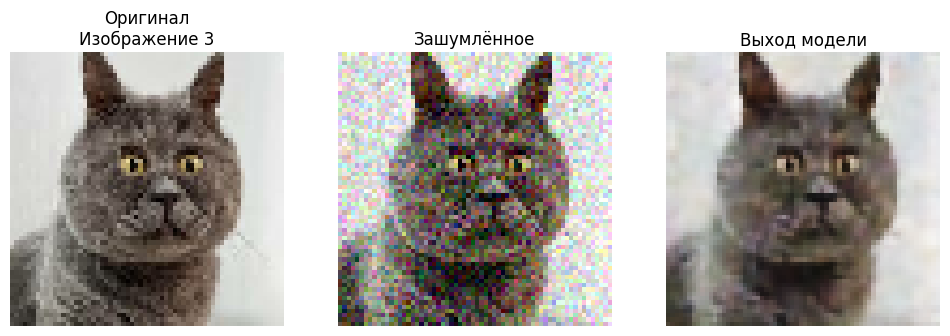

In [15]:
import matplotlib.pyplot as plt
import tensorflow as tf


def add_gaussian_noise(images, stddev=0.10):
    noise = tf.random.normal(tf.shape(images), mean=0.0, stddev=stddev)
    return tf.clip_by_value(images + noise, 0.0, 1.0)


def show_denoising_result(image_source, title_suffix=""):
    clean_img = load_image_for_demo(image_source, (64, 64))
    noisy_img = add_gaussian_noise(clean_img, stddev=0.10)
    denoised_img = denoising_model.predict(tf.expand_dims(noisy_img, 0), verbose=0)[0]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title(f"Оригинал\n{title_suffix}")
    plt.imshow(tf.clip_by_value(clean_img, 0.0, 1.0))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Зашумлённое")
    plt.imshow(tf.clip_by_value(noisy_img, 0.0, 1.0))
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Выход модели")
    plt.imshow(tf.clip_by_value(denoised_img, 0.0, 1.0))
    plt.axis("off")

    plt.show()


if "denoising_model" not in globals():
    print("Сначала выполните ячейку инициализации/обучения модели удаления шума.")
elif "demo_inputs" not in globals() or len(demo_inputs) == 0:
    print("Сначала выполните демонстрацию задания №1, чтобы получить входные изображения.")
else:
    for i, src in enumerate(demo_inputs, start=1):
        show_denoising_result(src, title_suffix=f"Изображение {i}")

## **Демонстрация результата задания №3: апскейлинг x2**

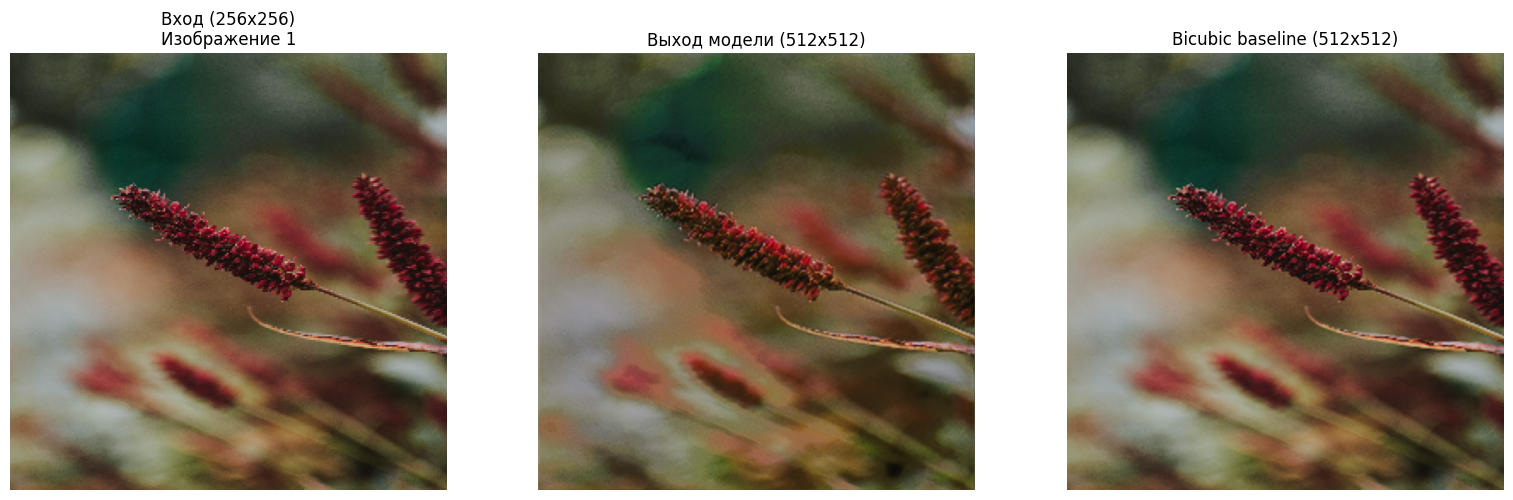

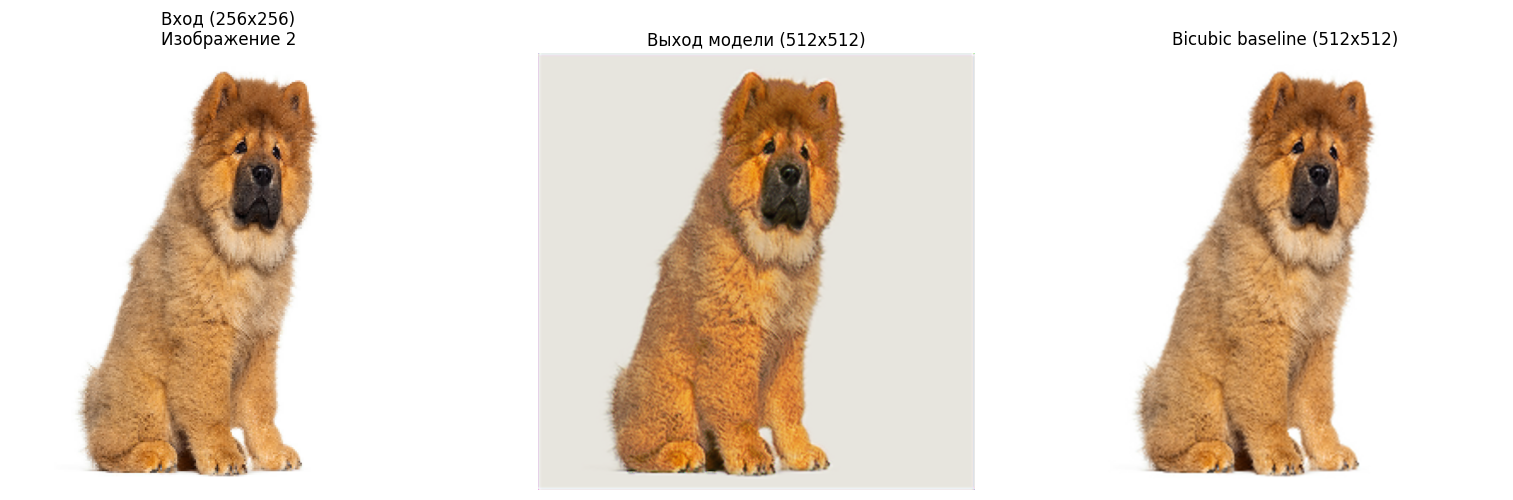

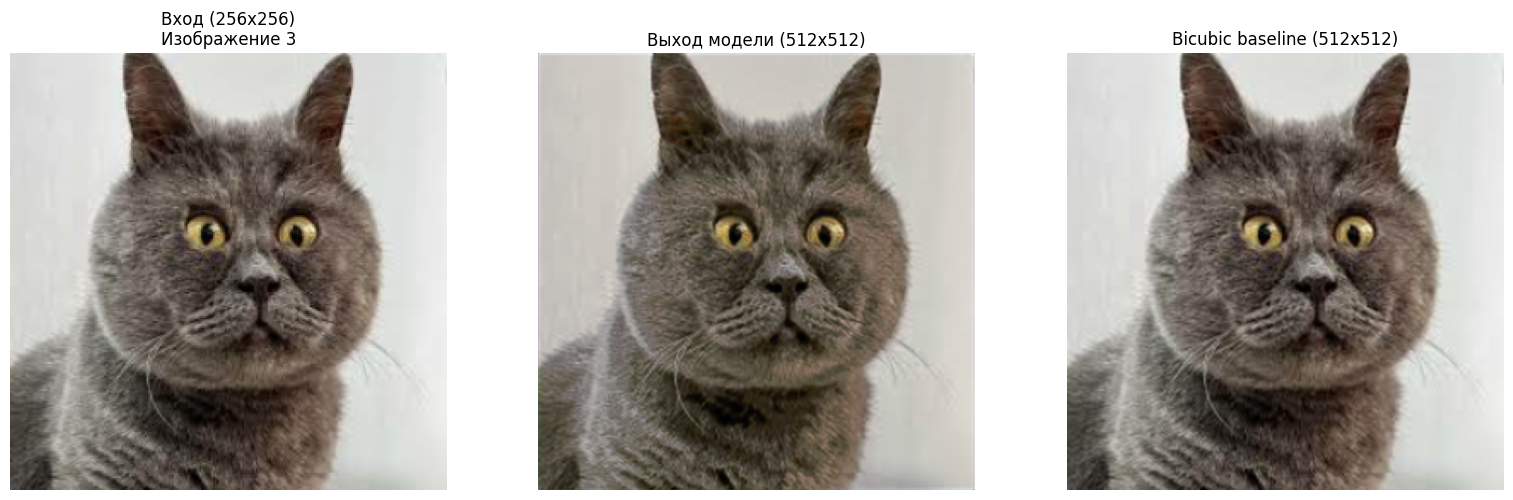

In [17]:
import matplotlib.pyplot as plt
import tensorflow as tf

def show_upscaling_result(image_source, title_suffix=""):
    lr_img = load_image_for_demo(image_source, (256, 256))

    model_upscaled = upscaling_model.predict(tf.expand_dims(lr_img, 0), verbose=0)[0]
    bicubic_upscaled = tf.image.resize(lr_img, (512, 512), method="bicubic")

    plt.figure(figsize=(16, 5))

    # Входное изображение
    plt.subplot(1, 3, 1)
    h, w = lr_img.shape[:2]
    plt.title(f"Вход ({w}x{h})\n{title_suffix}")
    plt.imshow(tf.clip_by_value(lr_img, 0.0, 1.0))
    plt.axis("off")

    # Результат модели
    plt.subplot(1, 3, 2)
    h_m, w_m = model_upscaled.shape[:2]
    plt.title(f"Выход модели ({w_m}x{h_m})")
    plt.imshow(tf.clip_by_value(model_upscaled, 0.0, 1.0))
    plt.axis("off")

    # Базовый апскейл (Bicubic)
    plt.subplot(1, 3, 3)
    h_b, w_b = bicubic_upscaled.shape[:2]
    plt.title(f"Bicubic baseline ({w_b}x{h_b})")
    plt.imshow(tf.clip_by_value(bicubic_upscaled, 0.0, 1.0))
    plt.axis("off")

    plt.tight_layout()
    plt.show()

if "upscaling_model" not in globals():
    print("Сначала выполните ячейку инициализации/обучения модели апскейлинга.")
elif "demo_inputs" not in globals() or len(demo_inputs) == 0:
    print("Сначала выполните демонстрацию задания №1, чтобы получить входные изображения.")
else:
    for i, src in enumerate(demo_inputs, start=1):
        show_upscaling_result(src, title_suffix=f"Изображение {i}")